# **Assignment 4 Solution Notebook**
## **Portfolio Replication**

### **Group 34**
- Aritra Dasgupta (MA25M005)
- Garima Sikka (DA25E052)
- Mehak Gupta (MA25M016)
- Shashikumar Khoba (EE25M115)




## Methods:
- **1. LASSO Regression** → stock selection
- **2. Autoencoder(Latent Feature Mapping, Communality based)** → stock selection
## Weighting (applied independently to each selection method):
- **A. Markowitz Mean-Variance Optimization**
- **B. Hierarchical Risk Parity (HRP)**


## **Section 0: Imports & Setup**

In [6]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn tensorflow keras cvxpy
%matplotlib inline
import os, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
HAS_TF = True
    
import cvxpy as cp
HAS_CVXPY = True

from scipy.optimize import minimize


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Section 1: Configuration and Constants

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────────────────────
DATA_DIR = "./Mega" if os.path.isdir("./Mega") else "./MEGA"
TRAIN_START = "2020-01-01"
TRAIN_END = "2024-6-30"
VALID_START = "2024-07-01"
VALID_END = "2025-06-30"
HOLDOUT_START = "2025-07-01"
HOLDOUT_END = "2025-12-31"

PREHOLDOUT_END = VALID_END

K_DEFAULT = 50
K_MAX_FINAL = 50
K_OPT_RANGE = range(K_MAX_FINAL, 9, -1)
SWEEP_MIN_K = 10
SWEEP_MAX_K = 100
SWEEP_STEP = 5
SELECTION_TOL = 0.30

TRADING_DAYS = 252
RIDGE_EPS = 1e-6
WEIGHT_REG = 1e-3
MAX_STOCK_WEIGHT = 0.08
SECTOR_CAP_BUFFER = 0.03
MIN_SECTOR_WEIGHT_FOR_QUOTA = 0.04
SECTOR_QUOTA_RELAX = 0.35
ROLLING_FOLDS = [
    ("2020-01-01", "2023-12-31", "2024-01-01", "2024-06-30"),
    ("2020-01-01", "2024-06-30", "2024-07-01", "2024-12-31"),
    ("2020-01-01", "2024-12-31", "2025-01-01", "2025-06-30"),
]

AE_MAX_LATENT = 12
AE_DROPOUT = 0.20
AE_EPOCHS = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# This map is only used to aggregate the provided constituent universe by sector.
# The dataset does not include official GICS weights or market caps, so sector drift
# is benchmarked against the mapped constituent universe rather than live index weights.
SECTOR_MAP = {
    "AAPL":"IT","MSFT":"IT","NVDA":"IT","AVGO":"IT","ORCL":"IT","CRM":"IT",
    "AMD":"IT","INTC":"IT","QCOM":"IT","TXN":"IT","AMAT":"IT","MU":"IT",
    "LRCX":"IT","KLAC":"IT","ADI":"IT","NXPI":"IT","STX":"IT","WDC":"IT",
    "HPQ":"IT","HPE":"IT","DELL":"IT","CSCO":"IT","IBM":"IT","ACN":"IT",
    "INTU":"IT","ADBE":"IT","NOW":"IT","PANW":"IT","FTNT":"IT","CDNS":"IT",
    "SNPS":"IT","KEYS":"IT","TRMB":"IT","EPAM":"IT","CTSH":"IT","DXC":"IT",
    "NTAP":"IT","FFIV":"IT","GLW":"IT","APH":"IT","TEL":"IT","ANET":"IT",
    "ADSK":"IT","FICO":"IT","GDDY":"IT","GEN":"IT","TYL":"IT","TER":"IT",
    "MPWR":"IT","MCHP":"IT","MSI":"IT","JBL":"IT","SMCI":"IT",
    "META":"Comm","GOOGL":"Comm","GOOG":"Comm","NFLX":"Comm","DIS":"Comm",
    "CMCSA":"Comm","T":"Comm","VZ":"Comm","TMUS":"Comm","CHTR":"Comm",
    "EA":"Comm","TTWO":"Comm","OMC":"Comm","WBD":"Comm","FOX":"Comm",
    "FOXA":"Comm","NWSA":"Comm","NWS":"Comm","LYV":"Comm","IPG":"Comm",
    "AMZN":"ConsDisc","TSLA":"ConsDisc","HD":"ConsDisc","MCD":"ConsDisc",
    "NKE":"ConsDisc","SBUX":"ConsDisc","LOW":"ConsDisc","TJX":"ConsDisc",
    "BKNG":"ConsDisc","ABNB":"ConsDisc","MAR":"ConsDisc","HLT":"ConsDisc",
    "GM":"ConsDisc","F":"ConsDisc","BBY":"ConsDisc","EBAY":"ConsDisc",
    "ROST":"ConsDisc","DHI":"ConsDisc","LEN":"ConsDisc","PHM":"ConsDisc",
    "NVR":"ConsDisc","POOL":"ConsDisc","HAS":"ConsDisc","MHK":"ConsDisc",
    "AZO":"ConsDisc","ORLY":"ConsDisc","LULU":"ConsDisc","DRI":"ConsDisc",
    "DPZ":"ConsDisc","YUM":"ConsDisc","CMG":"ConsDisc","ULTA":"ConsDisc",
    "RCL":"ConsDisc","CCL":"ConsDisc","NCLH":"ConsDisc","LVS":"ConsDisc",
    "MGM":"ConsDisc","WYNN":"ConsDisc","AAP":"ConsDisc","APTV":"ConsDisc",
    "WMT":"ConsStp","COST":"ConsStp","PG":"ConsStp","KO":"ConsStp",
    "PEP":"ConsStp","PM":"ConsStp","MO":"ConsStp","MDLZ":"ConsStp",
    "CL":"ConsStp","EL":"ConsStp","KMB":"ConsStp","CHD":"ConsStp",
    "CAG":"ConsStp","CPB":"ConsStp","GIS":"ConsStp","SJM":"ConsStp",
    "MKC":"ConsStp","HRL":"ConsStp","TSN":"ConsStp","KR":"ConsStp",
    "SYY":"ConsStp","ADM":"ConsStp","BG":"ConsStp","KDP":"ConsStp",
    "KHC":"ConsStp","CLX":"ConsStp","TAP":"ConsStp","LW":"ConsStp",
    "LLY":"Health","UNH":"Health","JNJ":"Health","ABBV":"Health","MRK":"Health",
    "TMO":"Health","ABT":"Health","DHR":"Health","BMY":"Health","AMGN":"Health",
    "GILD":"Health","ISRG":"Health","SYK":"Health","BSX":"Health","MDT":"Health",
    "ZTS":"Health","REGN":"Health","VRTX":"Health","MRNA":"Health","IQV":"Health",
    "CRL":"Health","MTD":"Health","BAX":"Health","BDX":"Health","COO":"Health",
    "HOLX":"Health","XRAY":"Health","HUM":"Health","CI":"Health","CVS":"Health",
    "ELV":"Health","CNC":"Health","MOH":"Health","HCA":"Health","PFE":"Health",
    "LH":"Health","IDXX":"Health","TECH":"Health","RVTY":"Health","PODD":"Health",
    "STE":"Health","WAT":"Health","CAH":"Health","MCK":"Health","DGX":"Health",
    "BRK-B":"Fin","JPM":"Fin","BAC":"Fin","WFC":"Fin","GS":"Fin","MS":"Fin",
    "C":"Fin","BLK":"Fin","SCHW":"Fin","AXP":"Fin","CB":"Fin","PGR":"Fin",
    "TRV":"Fin","ALL":"Fin","MET":"Fin","PRU":"Fin","AFL":"Fin","COF":"Fin",
    "SYF":"Fin","FITB":"Fin","KEY":"Fin","RF":"Fin","CFG":"Fin","HBAN":"Fin",
    "MTB":"Fin","USB":"Fin","PNC":"Fin","TFC":"Fin","ZION":"Fin","FHN":"Fin",
    "ICE":"Fin","CME":"Fin","NDAQ":"Fin","CBOE":"Fin","MSCI":"Fin","SPGI":"Fin",
    "MCO":"Fin","FDS":"Fin","BR":"Fin","NTRS":"Fin","STT":"Fin","BK":"Fin",
    "AIG":"Fin","AON":"Fin","AJG":"Fin","BRO":"Fin","MMC":"Fin","WTW":"Fin",
    "CINF":"Fin","RJF":"Fin","AIZ":"Fin","GL":"Fin","PFG":"Fin","BEN":"Fin",
    "KKR":"Fin","BX":"Fin","APO":"Fin","ARES":"Fin","AMP":"Fin","V":"Fin","MA":"Fin",
    "GE":"Ind","HON":"Ind","UNP":"Ind","UPS":"Ind","CAT":"Ind","DE":"Ind",
    "BA":"Ind","LMT":"Ind","RTX":"Ind","NOC":"Ind","GD":"Ind","LHX":"Ind",
    "MMM":"Ind","EMR":"Ind","ETN":"Ind","PH":"Ind","ROK":"Ind","ITW":"Ind",
    "IR":"Ind","GWW":"Ind","FAST":"Ind","FDX":"Ind","CSX":"Ind","NSC":"Ind",
    "DAL":"Ind","UAL":"Ind","LUV":"Ind","AAL":"Ind","EXPD":"Ind","CHRW":"Ind",
    "JBHT":"Ind","ODFL":"Ind","CTAS":"Ind","RSG":"Ind","WM":"Ind","ROL":"Ind",
    "VRSK":"Ind","CARR":"Ind","OTIS":"Ind","AME":"Ind","DOV":"Ind","XYL":"Ind",
    "PWR":"Ind","HWM":"Ind","JCI":"Ind","PCAR":"Ind","TT":"Ind","TDG":"Ind",
    "EFX":"Ind","FIX":"Ind","HUBB":"Ind","BLDR":"Ind","AXON":"Ind","URI":"Ind",
    "WAB":"Ind","TXT":"Ind","PAYX":"Ind",
    "XOM":"Energy","CVX":"Energy","COP":"Energy","EOG":"Energy","SLB":"Energy",
    "PSX":"Energy","VLO":"Energy","MPC":"Energy","OXY":"Energy","DVN":"Energy",
    "FANG":"Energy","APA":"Energy","HAL":"Energy","BKR":"Energy","KMI":"Energy",
    "WMB":"Energy","OKE":"Energy","TRGP":"Energy","EQT":"Energy","CTRA":"Energy",
    "MRO":"Energy","NOV":"Energy","XEC":"Energy","NBR":"Energy","NE":"Energy",
    "LIN":"Mat","APD":"Mat","ECL":"Mat","SHW":"Mat","FCX":"Mat","NEM":"Mat",
    "NUE":"Mat","STLD":"Mat","CF":"Mat","MOS":"Mat","FMC":"Mat","PPG":"Mat",
    "VMC":"Mat","MLM":"Mat","CRH":"Mat","IP":"Mat","PKG":"Mat","BALL":"Mat",
    "ALB":"Mat","CE":"Mat","DD":"Mat","DOW":"Mat","AVY":"Mat","IFF":"Mat",
    "AMT":"RE","PLD":"RE","CCI":"RE","EQIX":"RE","DLR":"RE","O":"RE",
    "SPG":"RE","PSA":"RE","EXR":"RE","AVB":"RE","EQR":"RE","MAA":"RE",
    "UDR":"RE","CPT":"RE","ARE":"RE","BXP":"RE","KIM":"RE","REG":"RE",
    "FRT":"RE","HST":"RE","VTR":"RE","WELL":"RE","SBAC":"RE","IRM":"RE",
    "INVH":"RE","DOC":"RE","VICI":"RE",
    "NEE":"Util","DUK":"Util","SO":"Util","D":"Util","AEP":"Util","EXC":"Util",
    "SRE":"Util","XEL":"Util","PEG":"Util","ED":"Util","WEC":"Util","ES":"Util",
    "ETR":"Util","FE":"Util","EIX":"Util","AEE":"Util","CMS":"Util","CNP":"Util",
    "NI":"Util","LNT":"Util","EVRG":"Util","PPL":"Util","AWK":"Util","ATO":"Util",
    "DTE":"Util","CEG":"Util","AES":"Util","PNW":"Util","VST":"Util",
}

SECTOR_FULL = {
    "IT":"Information Technology",
    "Comm":"Communication Services",
    "ConsDisc":"Consumer Discretionary",
    "ConsStp":"Consumer Staples",
    "Health":"Health Care",
    "Fin":"Financials",
    "Ind":"Industrials",
    "Energy":"Energy",
    "Mat":"Materials",
    "RE":"Real Estate",
    "Util":"Utilities",
    "Unknown":"Unknown / Unmapped",
}

## Section 2: Data Loading

## Data Layout:
- `~/MEGA/^GSPC.csv` – S&P 500 index
- `~/MEGA/<TICKER>.csv` – constituent stocks

## Splits:
- **Train+Test**: Jan 2020 – Jun 2025
- **Holdout**: Jul 2025 – Dec 2025

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. DATA LOADING
# ──────────────────────────────────────────────────────────────────────────────
def _numeric_close_frame(path, series_name):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index, utc=False).normalize()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    close_cols = [c for c in df.columns if "close" in c.lower() or c == "Close"]
    if not close_cols:
        close_cols = [df.columns[-1]]
    s = df[close_cols[0]].copy()
    s = pd.to_numeric(s, errors="coerce").dropna()
    s = s[~s.index.duplicated(keep="last")]
    return s.rename(series_name)


def canonical_ticker(ticker):
    return ticker.replace(".", "-")


def get_sector_label(ticker):
    return SECTOR_MAP.get(canonical_ticker(ticker), "Unknown")


def load_data(data_dir=DATA_DIR):
    print("=" * 70)
    print("LOADING DATA")
    print("=" * 70)

    gspc = _numeric_close_frame(os.path.join(data_dir, "^GSPC.csv"), "^GSPC").to_frame()

    files = sorted(
        f for f in os.listdir(data_dir)
        if f.endswith(".csv") and f not in {"^GSPC.csv", "sp500_tickers_cache.csv"}
    )
    print(f"  Found {len(files)} constituent files")

    prices = {}
    for f in files:
        ticker = f.replace(".csv", "")
        try:
            prices[ticker] = _numeric_close_frame(os.path.join(data_dir, f), ticker)
        except Exception:
            continue

    prices_df = pd.DataFrame(prices).sort_index()
    common_idx = gspc.index.intersection(prices_df.index)
    prices_df = prices_df.loc[common_idx].sort_index().ffill()
    gspc = gspc.loc[common_idx].sort_index()

    returns_df = prices_df.pct_change().replace([np.inf, -np.inf], np.nan).iloc[1:]
    gspc_ret = gspc["^GSPC"].pct_change().replace([np.inf, -np.inf], np.nan).iloc[1:]

    common_idx = returns_df.index.intersection(gspc_ret.index)
    returns_df = returns_df.loc[common_idx]
    gspc_ret = gspc_ret.loc[common_idx]

    missing_mask = returns_df.isnull().mean() < 0.10
    returns_df = returns_df.loc[:, missing_mask].fillna(0.0)

    print(f"  Benchmark dates    : {gspc_ret.index[0].date()} → {gspc_ret.index[-1].date()}")
    print(f"  Usable constituents: {returns_df.shape[1]}")
    return returns_df, gspc_ret


def split_data(
    returns_df,
    gspc_ret,
    train_start=TRAIN_START,
    train_end=TRAIN_END,
    valid_start=VALID_START,
    valid_end=VALID_END,
    holdout_start=HOLDOUT_START,
    holdout_end=HOLDOUT_END,
):
    train_mask = (returns_df.index >= train_start) & (returns_df.index <= train_end)
    valid_mask = (returns_df.index >= valid_start) & (returns_df.index <= valid_end)
    hold_mask = (returns_df.index >= holdout_start) & (returns_df.index <= holdout_end)

    X_train = returns_df.loc[train_mask]
    y_train = gspc_ret.loc[train_mask]
    X_valid = returns_df.loc[valid_mask]
    y_valid = gspc_ret.loc[valid_mask]
    X_hold = returns_df.loc[hold_mask]
    y_hold = gspc_ret.loc[hold_mask]
    return X_train, y_train, X_valid, y_valid, X_hold, y_hold


def build_rolling_folds(returns_df, gspc_ret):
    folds = []
    for tr_start, tr_end, va_start, va_end in ROLLING_FOLDS:
        train_mask = (returns_df.index >= tr_start) & (returns_df.index <= tr_end)
        valid_mask = (returns_df.index >= va_start) & (returns_df.index <= va_end)
        X_tr = returns_df.loc[train_mask]
        y_tr = gspc_ret.loc[train_mask]
        X_va = returns_df.loc[valid_mask]
        y_va = gspc_ret.loc[valid_mask]
        if len(X_tr) > 0 and len(X_va) > 0:
            folds.append((X_tr, y_tr, X_va, y_va))
    return folds


def compute_benchmark_sector_weights(universe_tickers):
    universe = pd.Index(sorted(set(map(canonical_ticker, universe_tickers))))
    sectors = pd.Series([get_sector_label(t) for t in universe], index=universe, name="Sector")
    sectors = sectors[sectors != "Unknown"]
    sector_weights = sectors.value_counts(normalize=True).sort_index()
    sector_weights.index = [SECTOR_FULL.get(s, s) for s in sector_weights.index]
    return sector_weights.sort_values(ascending=False)

### Section 3: Stock Selection Methods

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 2. STOCK SELECTION, WEIGHTING, AND EVALUATION HELPERS
# ──────────────────────────────────────────────────────────────────────────────
SELECTION_CACHE = {}
WEIGHT_CACHE = {}

GLOBAL_BENCHMARK_SECTOR_WEIGHTS = None


def _dataset_cache_key(X):
    return (str(X.index[0].date()), str(X.index[-1].date()), X.shape[0], X.shape[1])


def select_stocks(X_train, y_train, method, mode, k, verbose=False):
    key = (_dataset_cache_key(X_train), method, mode or "none", k)
    if key in SELECTION_CACHE:
        return SELECTION_CACHE[key]
    if method == "LASSO":
        selected, _ = select_lasso(X_train, y_train, k=k, verbose=verbose)
    else:
        selected, _ = select_autoencoder(X_train, y_train, k=k, mode=mode, verbose=verbose)
    SELECTION_CACHE[key] = selected
    return selected


def sector_balanced_subset(columns, importance, k, benchmark_sector_weights):
    columns = list(columns)
    importance = pd.Series(np.asarray(importance, dtype=float), index=columns)
    ranked = importance.sort_values(ascending=False)

    if benchmark_sector_weights is None:
        return ranked.head(k).index.tolist()

    sector_map = pd.Series({c: SECTOR_FULL.get(get_sector_label(c), SECTOR_FULL["Unknown"]) for c in columns})
    mapped = sector_map[sector_map != SECTOR_FULL["Unknown"]]
    if mapped.empty:
        return ranked.head(k).index.tolist()

    sector_targets = (benchmark_sector_weights * k).round().astype(int)
    active_sectors = benchmark_sector_weights[benchmark_sector_weights >= MIN_SECTOR_WEIGHT_FOR_QUOTA].index.tolist()
    for sector in active_sectors:
        if sector in mapped.values and sector_targets.get(sector, 0) == 0:
            sector_targets.loc[sector] = 1

    available = mapped.value_counts()
    sector_targets = sector_targets.reindex(available.index, fill_value=0)
    sector_targets = pd.concat([sector_targets, available], axis=1)
    sector_targets.columns = ["target", "available"]
    sector_targets["target"] = np.minimum(sector_targets["target"], sector_targets["available"])

    current = int(sector_targets["target"].sum())
    if current > k:
        for sector in sector_targets.sort_values("target", ascending=False).index:
            while sector_targets.loc[sector, "target"] > 0 and current > k:
                sector_targets.loc[sector, "target"] -= 1
                current -= 1
    elif current < k:
        deficits = benchmark_sector_weights.reindex(sector_targets.index).fillna(0).sort_values(ascending=False).index.tolist()
        changed = True
        while current < k and changed:
            changed = False
            for sector in deficits:
                if current >= k:
                    break
                if sector_targets.loc[sector, "target"] < sector_targets.loc[sector, "available"]:
                    sector_targets.loc[sector, "target"] += 1
                    current += 1
                    changed = True

    selected = []
    for sector, row in sector_targets.iterrows():
        n_take = int(row["target"])
        if n_take <= 0:
            continue
        sector_names = ranked.loc[mapped[mapped == sector].index].head(n_take).index.tolist()
        selected.extend(sector_names)

    selected = list(dict.fromkeys(selected))
    if len(selected) < k:
        remaining = [name for name in ranked.index.tolist() if name not in selected]
        selected.extend(remaining[: k - len(selected)])

    return selected[:k]


def select_lasso(X_train, y_train, k=K_DEFAULT, verbose=True):
    if verbose:
        print(f"\n[LASSO] Selecting top-{k} stocks")
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_train)
    # Using TimeSeriesSplit to preserve temporal order in cross-validation.
    # Standard KFold (cv=5) shuffles data randomly, which breaks the time-series
    # structure and allows future data to leak into training folds.
    tscv = TimeSeriesSplit(n_splits=5)
    lcv = LassoCV(cv=tscv, max_iter=5000, random_state=RANDOM_SEED, n_jobs=-1)
    lcv.fit(X_sc, y_train.values)
    coef_abs = np.abs(lcv.coef_)

    # Stronger regularisation: do not relax alpha aggressively.
    if np.sum(coef_abs > 0) < k:
        for alpha in np.linspace(max(lcv.alpha_ * 0.35, 1e-5), lcv.alpha_, 15):
            model = Lasso(alpha=alpha, max_iter=10000)
            model.fit(X_sc, y_train.values)
            if np.sum(np.abs(model.coef_) > 0) >= k:
                coef_abs = np.abs(model.coef_)
                break

    top_idx = np.argsort(coef_abs)[-k:]
    selected = X_train.columns[top_idx].tolist()
    return selected, coef_abs


def select_autoencoder(X_train, y_train, k=K_DEFAULT, mode="latent", verbose=True):
    if verbose:
        print(f"\n[AUTOENCODER {mode}] Selecting top-{k} stocks")

    X_np = X_train.values.astype(np.float32)
    y_np = y_train.values.astype(np.float32)
    mu = X_np.mean(axis=0, keepdims=True)
    std = X_np.std(axis=0, keepdims=True) + 1e-8
    X_sc = (X_np - mu) / std

    if HAS_TF:
        tf.random.set_seed(RANDOM_SEED)
        n_features = X_sc.shape[1]
        latent_dim = max(6, min(AE_MAX_LATENT, n_features // 10))

        inp = keras.Input(shape=(n_features,))
        enc = keras.layers.Dense(96, activation="relu")(inp)
        enc = keras.layers.Dropout(AE_DROPOUT)(enc)
        enc = keras.layers.Dense(32, activation="relu")(enc)
        lat = keras.layers.Dense(latent_dim, activation="linear", name="latent")(enc)
        dec = keras.layers.Dense(32, activation="relu")(lat)
        dec = keras.layers.Dense(96, activation="relu")(dec)
        out = keras.layers.Dense(n_features, activation="linear")(dec)

        ae = keras.Model(inp, out)
        ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

        # Keras validation_split takes the LAST fraction of the sequence,
        # which preserves temporal order for time-series data.
        X_noisy = X_sc + 0.04 * np.random.randn(*X_sc.shape).astype(np.float32)
        ae.fit(
            X_noisy,
            X_sc,
            epochs=AE_EPOCHS,
            batch_size=32,
            verbose=0,
            validation_split=0.1,
            callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        )

        if mode == "latent":
            encoder = keras.Model(inp, lat)
            Z = encoder.predict(X_sc, verbose=0)
            corrs = np.array([
                0.0 if np.std(Z[:, j]) < 1e-12 else np.corrcoef(Z[:, j], y_np)[0, 1]
                for j in range(Z.shape[1])
            ])
            best_dim = int(np.nanargmax(np.abs(np.nan_to_num(corrs, nan=0.0))))
            w1 = np.abs(ae.layers[1].get_weights()[0])   # Input -> Dense(96): shape (n_features, 96)
            w2 = np.abs(ae.layers[3].get_weights()[0])   # Dense(96) -> Dense(32): shape (96, 32)
            w3 = np.abs(ae.get_layer("latent").get_weights()[0][:, best_dim])  # Dense(32) -> latent dim: shape (32,)
            importance = w1 @ (w2 @ w3)                  # (n_features,) path-importance to best latent dim
        else:
            X_recon = ae.predict(X_sc, verbose=0)
            mse_per_stock = np.mean((X_sc - X_recon) ** 2, axis=0)
            importance = 1.0 - mse_per_stock
    else:
        from sklearn.decomposition import PCA

        n_components = max(5, min(12, X_sc.shape[1] // 12))
        pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
        Z = pca.fit_transform(X_sc)
        if mode == "latent":
            corrs = np.array([
                0.0 if np.std(Z[:, j]) < 1e-12 else np.corrcoef(Z[:, j], y_np)[0, 1]
                for j in range(Z.shape[1])
            ])
            best_dim = int(np.nanargmax(np.abs(np.nan_to_num(corrs, nan=0.0))))
            importance = np.abs(pca.components_[best_dim])
        else:
            X_recon = pca.inverse_transform(Z)
            mse_per_stock = np.mean((X_sc - X_recon) ** 2, axis=0)
            importance = 1.0 - mse_per_stock

    top_idx = np.argsort(np.asarray(importance))[-k:]
    selected = X_train.columns[top_idx].tolist()
    return selected, importance


def normalize_weights(weights, assets):
    w = pd.Series(weights, index=assets, dtype=float).fillna(0.0).clip(lower=0.0)
    if w.sum() <= 0:
        w[:] = 1.0 / len(w)
    else:
        w = w / w.sum()
    return w.to_dict()


def portfolio_returns(X, weights):
    w = pd.Series(weights, dtype=float)
    cols = [c for c in w.index if c in X.columns]
    if not cols:
        return pd.Series(index=X.index, data=0.0)
    w = w.loc[cols]
    w = w / w.sum()
    return X[cols].mul(w, axis=1).sum(axis=1)


def annual_tracking_error(port_ret, bench_ret):
    active = port_ret - bench_ret
    return active.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100


def compute_metrics(port_ret, bench_ret, label):
    active = (port_ret - bench_ret).dropna()
    aligned_bench = bench_ret.loc[active.index]
    ann_te = active.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100
    ann_active = active.mean() * TRADING_DAYS * 100
    ann_ir = ann_active / ann_te if ann_te > 1e-12 else np.nan
    corr = port_ret.loc[aligned_bench.index].corr(aligned_bench)
    r2 = 1.0 - ((active ** 2).sum() / ((aligned_bench - aligned_bench.mean()) ** 2).sum())
    return {
        "Label": label,
        "Ann TE (%)": ann_te,
        "Ann IR": ann_ir,
        "Corr": corr,
        "R²": r2,
        "Ann Active(%)": ann_active,
    }


def sector_cap_lookup(benchmark_sector_weights):
    caps = benchmark_sector_weights.to_dict()
    return {sector: min(1.0, weight + SECTOR_CAP_BUFFER) for sector, weight in caps.items()}


def enforce_weight_constraints(weights, benchmark_sector_weights):
    w = pd.Series(weights, dtype=float).clip(lower=0.0)
    if w.sum() <= 0:
        w[:] = 1.0 / len(w)
    w = w / w.sum()

    caps = sector_cap_lookup(benchmark_sector_weights)
    sector_labels = pd.Series({ticker: SECTOR_FULL.get(get_sector_label(ticker), SECTOR_FULL["Unknown"]) for ticker in w.index})

    for _ in range(10):
        w = w.clip(upper=MAX_STOCK_WEIGHT)
        if w.sum() <= 0:
            w[:] = 1.0 / len(w)
        w = w / w.sum()

        sector_sums = w.groupby(sector_labels).sum()
        changed = False
        for sector, total in sector_sums.items():
            cap = caps.get(sector, 1.0)
            if total > cap + 1e-10:
                members = sector_labels[sector_labels == sector].index
                w.loc[members] *= cap / total
                changed = True

        remaining = 1.0 - w.sum()
        if remaining <= 1e-8:
            w = w / w.sum()
            if not changed:
                break
            continue

        sector_sums = w.groupby(sector_labels).sum()
        headroom = pd.Series(MAX_STOCK_WEIGHT, index=w.index) - w
        for asset in headroom.index:
            sector = sector_labels[asset]
            headroom[asset] = min(headroom[asset], caps.get(sector, 1.0) - sector_sums.get(sector, 0.0))
        eligible = headroom[headroom > 1e-8]
        if eligible.empty:
            break
        add = remaining * (eligible / eligible.sum())
        w.loc[eligible.index] += add

    w = w.clip(lower=0.0)
    w = w / w.sum()
    return w.to_dict()


def markowitz_weights(X_train, y_train, selected, benchmark_sector_weights):
    X_sel = X_train[selected].values
    y = y_train.values.reshape(-1, 1)
    # Compute covariance of (r_i - r_b) for each stock i.
    # w' Cov(R - r_b) w = Var(w'R - r_b) = TE^2  (since sum(w)=1).
    diff = X_sel - y
    te_cov = np.cov(diff, rowvar=False) + RIDGE_EPS * np.eye(len(selected))

    sector_names = [SECTOR_FULL.get(get_sector_label(t), SECTOR_FULL["Unknown"]) for t in selected]
    sector_caps = sector_cap_lookup(benchmark_sector_weights)

    if HAS_CVXPY:
        w = cp.Variable(len(selected))
        objective = cp.Minimize(cp.quad_form(w, te_cov) + WEIGHT_REG * cp.sum_squares(w))
        constraints = [cp.sum(w) == 1, w >= 0, w <= MAX_STOCK_WEIGHT]
        for sector in sorted(set(sector_names)):
            idx = [i for i, s in enumerate(sector_names) if s == sector]
            cap = sector_caps.get(sector, 1.0)
            constraints.append(cp.sum(w[idx]) <= cap)
        problem = cp.Problem(objective, constraints)
        try:
            problem.solve(solver=cp.OSQP, verbose=False)
        except Exception:
            problem.solve(solver=cp.SCS, verbose=False)
        if w.value is not None:
            return enforce_weight_constraints(pd.Series(w.value, index=selected), benchmark_sector_weights)

    x0 = np.full(len(selected), 1.0 / len(selected))

    def objective_fn(w_):
        return float(w_ @ te_cov @ w_ + WEIGHT_REG * np.sum(w_ ** 2))

    constraints = {"type": "eq", "fun": lambda w_: np.sum(w_) - 1.0}
    bounds = [(0.0, MAX_STOCK_WEIGHT)] * len(selected)
    res = minimize(objective_fn, x0=x0, bounds=bounds, constraints=constraints, method="SLSQP")
    if res.success:
        return enforce_weight_constraints(pd.Series(res.x, index=selected), benchmark_sector_weights)
    return enforce_weight_constraints(pd.Series(x0, index=selected), benchmark_sector_weights)


def _get_quasi_diag(link):
    num_items = int(link[-1, 3])
    sort_ix = [int(link[-1, 0]), int(link[-1, 1])]
    while any(i >= num_items for i in sort_ix):
        new_sort_ix = []
        for item in sort_ix:
            if item < num_items:
                new_sort_ix.append(int(item))
            else:
                left = int(link[item - num_items, 0])
                right = int(link[item - num_items, 1])
                new_sort_ix.extend([left, right])
        sort_ix = new_sort_ix
    return sort_ix


def _cluster_var(cov, items):
    cov_slice = cov.loc[items, items]
    ivp = 1.0 / np.diag(cov_slice.values)
    ivp = ivp / ivp.sum()
    return float(ivp @ cov_slice.values @ ivp)


def hrp_weights(X_train, selected, benchmark_sector_weights):
    corr = X_train[selected].corr().fillna(0.0)
    cov = pd.DataFrame(
        X_train[selected].cov().fillna(0.0).values + RIDGE_EPS * np.eye(len(selected)),
        index=selected,
        columns=selected,
    )
    dist = np.sqrt(np.clip((1.0 - corr) / 2.0, 0.0, 1.0))
    # "single" linkage is the canonical choice
    link = linkage(squareform(dist.values, checks=False), method="single")
    sort_ix = corr.index[_get_quasi_diag(link)].tolist()

    weights = pd.Series(1.0, index=sort_ix)
    clusters = [sort_ix]
    while clusters:
        clusters = [c[i:j] for c in clusters for i, j in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            if i + 1 >= len(clusters):
                continue
            c1 = clusters[i]
            c2 = clusters[i + 1]
            var1 = _cluster_var(cov, c1)
            var2 = _cluster_var(cov, c2)
            alpha = 1.0 - var1 / (var1 + var2)
            weights[c1] *= alpha
            weights[c2] *= 1.0 - alpha
    return enforce_weight_constraints(weights, benchmark_sector_weights)


def build_weights(X_train, y_train, selected, weighting, benchmark_sector_weights):
    cache_key = (_dataset_cache_key(X_train), weighting, tuple(selected))
    if cache_key in WEIGHT_CACHE:
        return WEIGHT_CACHE[cache_key]
    if weighting == "Markowitz":
        weights = markowitz_weights(X_train, y_train, selected, benchmark_sector_weights)
    elif weighting == "HRP":
        weights = hrp_weights(X_train, selected, benchmark_sector_weights)
    else:
        raise ValueError(f"Unknown weighting method: {weighting}")
    WEIGHT_CACHE[cache_key] = weights
    return weights


def evaluate_on_folds(method, mode, weighting, k, folds, benchmark_sector_weights):
    te_scores = []
    for X_tr, y_tr, X_va, y_va in folds:
        if method == "LASSO":
            selected, _ = select_lasso(X_tr, y_tr, k=k, verbose=False)
        else:
            selected, _ = select_autoencoder(X_tr, y_tr, k=k, mode=mode, verbose=False)
        weights = build_weights(X_tr, y_tr, selected, weighting, benchmark_sector_weights)
        ret_valid = portfolio_returns(X_va, weights)
        te_scores.append(annual_tracking_error(ret_valid, y_va))
    return float(np.mean(te_scores)), float(np.std(te_scores))


def choose_sparse_k(candidate_rows):
    df = pd.DataFrame(candidate_rows).sort_values("k")
    best_te = df["cv_te_mean"].min()
    eligible = df[df["cv_te_mean"] <= best_te + SELECTION_TOL]
    chosen = eligible.sort_values(["k", "cv_te_std"]).iloc[0]
    return int(chosen["k"]), df


def sparsity_sweep(preholdout_returns, preholdout_bench, X_hold, y_hold, folds,
                   method, weighting, benchmark_sector_weights, mode=None, k_values=None):
    if k_values is None:
        max_k = min(SWEEP_MAX_K, preholdout_returns.shape[1])
        k_values = list(range(max_k, SWEEP_MIN_K - 1, -SWEEP_STEP))

    print(f"  Sweep: {method} {mode or ''} + {weighting} | k = {k_values[0]}..{k_values[-1]}")
    rows = []
    for k in k_values:
        cv_te_mean, cv_te_std = evaluate_on_folds(method, mode, weighting, k, folds, benchmark_sector_weights)
        if method == "LASSO":
            selected, _ = select_lasso(preholdout_returns, preholdout_bench, k=k, verbose=False)
        else:
            selected, _ = select_autoencoder(preholdout_returns, preholdout_bench, k=k, mode=mode, verbose=False)
        weights = build_weights(preholdout_returns, preholdout_bench, selected, weighting, benchmark_sector_weights)
        ret_hold = portfolio_returns(X_hold, weights)
        te_holdout = annual_tracking_error(ret_hold, y_hold)
        print(f"    k={k:3d}  CV TE={cv_te_mean:.3f}% ± {cv_te_std:.3f}  Holdout TE={te_holdout:.3f}%")
        rows.append(
            {
                "k": k,
                "TE_valid": cv_te_mean,
                "TE_valid_std": cv_te_std,
                "TE_holdout": te_holdout,
            }
        )
    return pd.DataFrame(rows).sort_values("k", ascending=False).reset_index(drop=True)


def sector_drift(selected, weights, benchmark_sector_weights, label):
    port_weights = pd.Series(weights, dtype=float)
    sector_codes = pd.Series({ticker: get_sector_label(ticker) for ticker in port_weights.index})
    mapped = sector_codes[sector_codes != "Unknown"].map(SECTOR_FULL)
    port_weights = port_weights.loc[mapped.index]
    portfolio_sector_weights = port_weights.groupby(mapped).sum()
    portfolio_sector_weights = portfolio_sector_weights / portfolio_sector_weights.sum()
    all_sectors = sorted(set(benchmark_sector_weights.index).union(portfolio_sector_weights.index))
    benchmark = benchmark_sector_weights.reindex(all_sectors, fill_value=0.0)
    portfolio = portfolio_sector_weights.reindex(all_sectors, fill_value=0.0)
    return pd.DataFrame(
        {
            "Sector": all_sectors,
            "Benchmark Weight": benchmark.values,
            "Portfolio Weight": portfolio.values,
            "Drift": (portfolio - benchmark).values,
            "Label": label,
        }
    )

### Section 4: Finding Optimal k for Each Model

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 3. MODEL SELECTION WITH ROLLING VALIDATION / HOLDOUT
# ──────────────────────────────────────────────────────────────────────────────
returns_df, gspc_ret = load_data()
X_train, y_train, X_valid, y_valid, X_hold, y_hold = split_data(returns_df, gspc_ret)

prehold_mask = returns_df.index <= PREHOLDOUT_END
X_prehold = returns_df.loc[prehold_mask]
y_prehold = gspc_ret.loc[prehold_mask]
rolling_folds = build_rolling_folds(X_prehold, y_prehold)

print(f"\nTrain shape     : {X_train.shape}")
print(f"Validation shape: {X_valid.shape}")
print(f"Holdout shape   : {X_hold.shape}")
print(f"Rolling folds   : {len(rolling_folds)}")

all_tickers = returns_df.columns.tolist()
benchmark_sector_weights = compute_benchmark_sector_weights(all_tickers)
GLOBAL_BENCHMARK_SECTOR_WEIGHTS = benchmark_sector_weights

models = [
    ("LASSO", None, "Markowitz"),
    ("LASSO", None, "HRP"),
    ("Autoencoder", "latent", "Markowitz"),
    ("Autoencoder", "latent", "HRP"),
    ("Autoencoder", "communality", "Markowitz"),
    ("Autoencoder", "communality", "HRP"),
]

results_all = {}
model_selection_summary = {}

for method, mode, weighting in models:
    print(f"\n--- Rolling validation for {method} {mode or ''} + {weighting} ---")
    candidates = []
    for k in K_OPT_RANGE:
        cv_te_mean, cv_te_std = evaluate_on_folds(method, mode, weighting, k, rolling_folds, benchmark_sector_weights)
        candidates.append({"k": k, "cv_te_mean": cv_te_mean, "cv_te_std": cv_te_std})

    chosen_k, selection_df = choose_sparse_k(candidates)
    model_selection_summary[(method, mode, weighting)] = selection_df

    if method == "LASSO":
        selected, _ = select_lasso(X_prehold, y_prehold, k=chosen_k, verbose=False)
    else:
        selected, _ = select_autoencoder(X_prehold, y_prehold, k=chosen_k, mode=mode, verbose=False)

    weights = build_weights(X_prehold, y_prehold, selected, weighting, benchmark_sector_weights)
    ret_prehold = portfolio_returns(X_prehold, weights)
    ret_hold = portfolio_returns(X_hold, weights)
    ret_train = ret_prehold.loc[X_train.index]
    ret_valid = ret_prehold.loc[X_valid.index]

    method_label = f"{method}_{mode}" if mode else method
    results_all[(method_label, weighting)] = {
        "k": chosen_k,
        "selected": selected,
        "weights": weights,
        "ret_train": ret_train,
        "ret_valid": ret_valid,
        "ret_hold": ret_hold,
        "cv_te_mean": float(selection_df.loc[selection_df["k"] == chosen_k, "cv_te_mean"].iloc[0]),
        "cv_te_std": float(selection_df.loc[selection_df["k"] == chosen_k, "cv_te_std"].iloc[0]),
        "metrics_train": compute_metrics(ret_train, y_train, f"{method_label}+{weighting} (Train)"),
        "metrics_valid": compute_metrics(ret_valid, y_valid, f"{method_label}+{weighting} (Validation Diagnostic)"),
        "metrics_hold": compute_metrics(ret_hold, y_hold, f"{method_label}+{weighting} (Holdout)"),
    }
    print(
        f"  Chosen k={chosen_k} | mean rolling TE={results_all[(method_label, weighting)]['cv_te_mean']:.3f}% "
        f"+/- {results_all[(method_label, weighting)]['cv_te_std']:.3f}"
    )

best_model_key = min(results_all, key=lambda key: results_all[key]["cv_te_mean"])
print(f"\nBest validation model: {best_model_key[0]} + {best_model_key[1]}")
print(f"Best rolling-val TE  : {results_all[best_model_key]['cv_te_mean']:.3f}%")
print(f"Holdout TE for best  : {results_all[best_model_key]['metrics_hold']['Ann TE (%)']:.3f}%")


LOADING DATA
  Found 583 constituent files
  Benchmark dates    : 2020-01-03 → 2026-01-27
  Usable constituents: 559

Train shape     : (1129, 559)
Validation shape: (250, 559)
Holdout shape   : (128, 559)
Rolling folds   : 3

--- Rolling validation for LASSO  + Markowitz ---
  Chosen k=40 | mean rolling TE=3.904% +/- 0.567

--- Rolling validation for LASSO  + HRP ---
  Chosen k=39 | mean rolling TE=4.654% +/- 0.272

--- Rolling validation for Autoencoder latent + Markowitz ---
  Chosen k=34 | mean rolling TE=6.229% +/- 1.028

--- Rolling validation for Autoencoder latent + HRP ---
  Chosen k=33 | mean rolling TE=7.775% +/- 0.338

--- Rolling validation for Autoencoder communality + Markowitz ---
  Chosen k=46 | mean rolling TE=9.643% +/- 0.628

--- Rolling validation for Autoencoder communality + HRP ---
  Chosen k=38 | mean rolling TE=9.619% +/- 0.667

Best validation model: LASSO + Markowitz
Best rolling-val TE  : 3.904%
Holdout TE for best  : 4.271%


### Section 5: Plotting Cumulative Returns

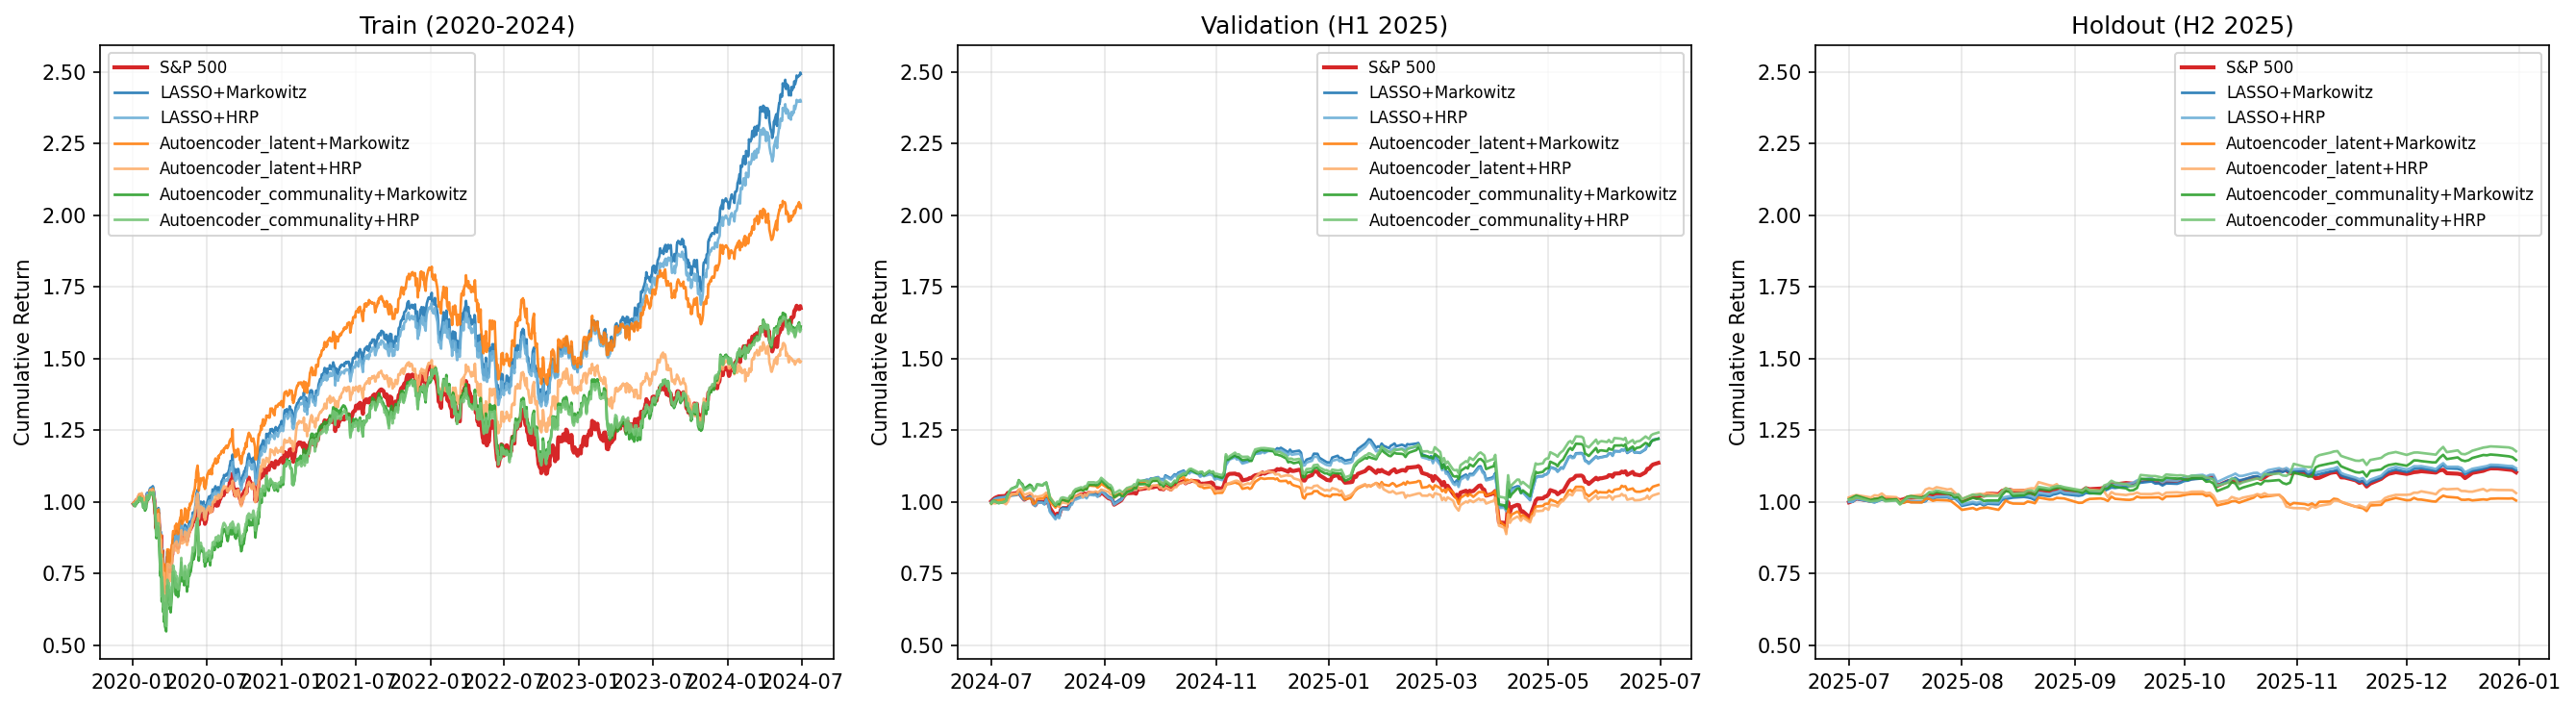

Saved fig1_cumulative_returns.png


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# 4. CUMULATIVE RETURNS
# ──────────────────────────────────────────────────────────────────────────────
os.makedirs("./Outputs", exist_ok=True)
plt.rcParams.update({"font.size": 10, "figure.dpi": 150})

COLORS = {
    "LASSO+Markowitz": "#1f77b4",
    "LASSO+HRP": "#6baed6",
    "Autoencoder_latent+Markowitz": "#ff7f0e",
    "Autoencoder_latent+HRP": "#fdae6b",
    "Autoencoder_communality+Markowitz": "#2ca02c",
    "Autoencoder_communality+HRP": "#74c476",
    "Benchmark": "#d62728",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
panels = [
    ("Train (2020-2024)", y_train, "ret_train"),
    ("Validation (H1 2025)", y_valid, "ret_valid"),
    ("Holdout (H2 2025)", y_hold, "ret_hold"),
]

for ax, (title, benchmark, ret_key) in zip(axes, panels):
    ax.plot(benchmark.index, (1 + benchmark).cumprod(), label="S&P 500", color=COLORS["Benchmark"], lw=2)
    for (method, weighting), result in results_all.items():
        series = result[ret_key]
        ax.plot(
            series.index,
            (1 + series).cumprod(),
            label=f"{method}+{weighting}",
            color=COLORS.get(f"{method}+{weighting}", None),
            lw=1.3,
            alpha=0.9,
        )
    ax.set_title(title)
    ax.set_ylabel("Cumulative Return")
    ax.tick_params(axis="y", labelleft=True)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join("./Outputs", "fig1_cumulative_returns.png"), bbox_inches="tight")
plt.show()
print("Saved fig1_cumulative_returns.png")

### Section 6: Sweeps and Sparsity vs TE

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# 5. SPARSITY SWEEPS AND SECTOR DRIFT DATA
# ──────────────────────────────────────────────────────────────────────────────
print("Starting sparsity sweeps (k = 100 down to 10, step 5)...")
print("Each sweep runs 3 rolling CV folds per k value.\n")

sweep_lasso_mk = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                method="LASSO", weighting="Markowitz",
                                benchmark_sector_weights=benchmark_sector_weights)

sweep_lasso_hrp = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                 method="LASSO", weighting="HRP",
                                 benchmark_sector_weights=benchmark_sector_weights)

sweep_ae_latent_mk = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                    method="Autoencoder", mode="latent", weighting="Markowitz",
                                    benchmark_sector_weights=benchmark_sector_weights)

sweep_ae_latent_hrp = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                     method="Autoencoder", mode="latent", weighting="HRP",
                                     benchmark_sector_weights=benchmark_sector_weights)

sweep_ae_comm_mk = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                  method="Autoencoder", mode="communality", weighting="Markowitz",
                                  benchmark_sector_weights=benchmark_sector_weights)

sweep_ae_comm_hrp = sparsity_sweep(X_prehold, y_prehold, X_hold, y_hold, rolling_folds,
                                   method="Autoencoder", mode="communality", weighting="HRP",
                                   benchmark_sector_weights=benchmark_sector_weights)

print("\nAll sweeps complete.")

sector_frames = {}
for (method, weighting), result in results_all.items():
    sector_frames[f"{method}+{weighting}"] = sector_drift(
        result["selected"],
        result["weights"],
        benchmark_sector_weights,
        f"{method}+{weighting}",
    )

best_sector_df = sector_frames[f"{best_model_key[0]}+{best_model_key[1]}"].copy()

Starting sparsity sweeps (k = 100 down to 10, step 5)...
Each sweep runs 3 rolling CV folds per k value.

  Sweep: LASSO  + Markowitz | k = 100..10
    k=100  CV TE=3.800% ± 0.185  Holdout TE=4.440%
    k= 95  CV TE=3.846% ± 0.237  Holdout TE=4.458%
    k= 90  CV TE=3.834% ± 0.264  Holdout TE=4.550%
    k= 85  CV TE=3.750% ± 0.215  Holdout TE=4.426%
    k= 80  CV TE=3.734% ± 0.150  Holdout TE=4.196%
    k= 75  CV TE=3.731% ± 0.127  Holdout TE=4.209%
    k= 70  CV TE=3.732% ± 0.145  Holdout TE=4.183%
    k= 65  CV TE=3.698% ± 0.127  Holdout TE=3.986%
    k= 60  CV TE=3.692% ± 0.112  Holdout TE=4.068%
    k= 55  CV TE=3.746% ± 0.058  Holdout TE=4.089%
    k= 50  CV TE=3.718% ± 0.088  Holdout TE=4.368%
    k= 45  CV TE=3.818% ± 0.260  Holdout TE=4.124%
    k= 40  CV TE=3.904% ± 0.567  Holdout TE=4.271%
    k= 35  CV TE=4.510% ± 0.430  Holdout TE=4.332%
    k= 30  CV TE=4.621% ± 0.415  Holdout TE=4.252%
    k= 25  CV TE=4.872% ± 0.208  Holdout TE=4.586%
    k= 20  CV TE=5.435% ± 0.228  Hol

### Section 7: Sector Drift Calculation and Plotting

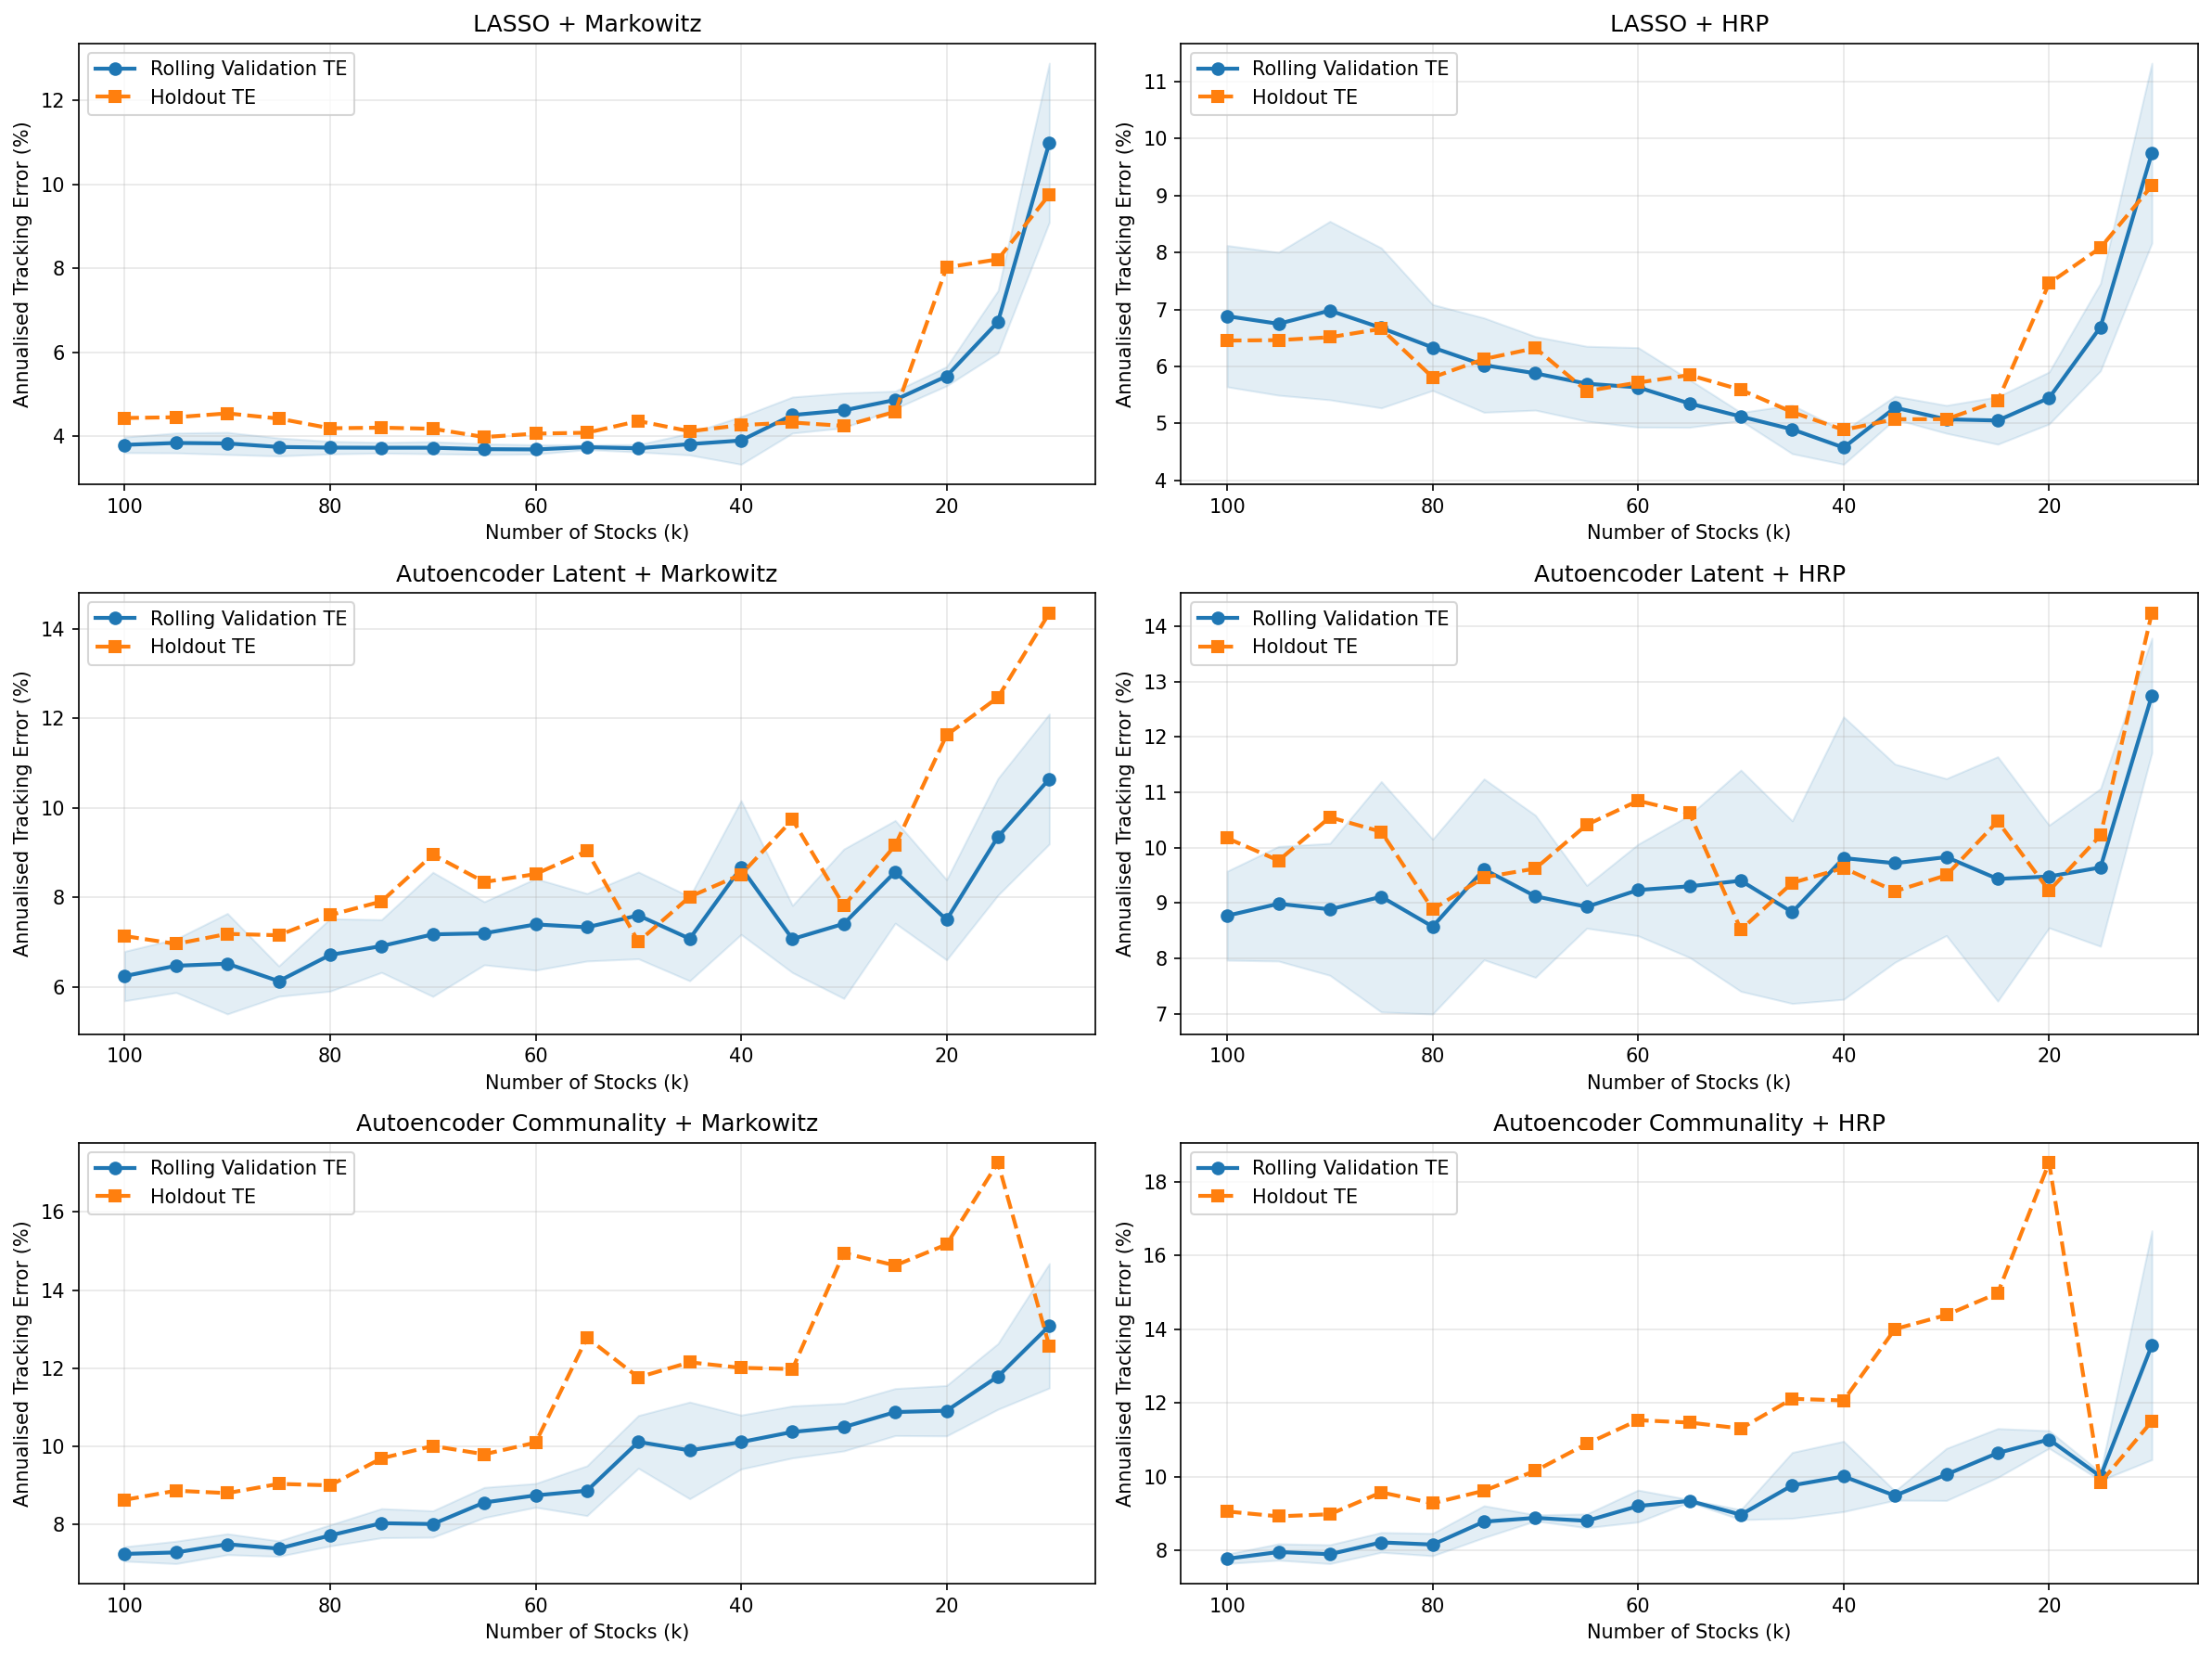

Saved fig2_sparsity_vs_te.png


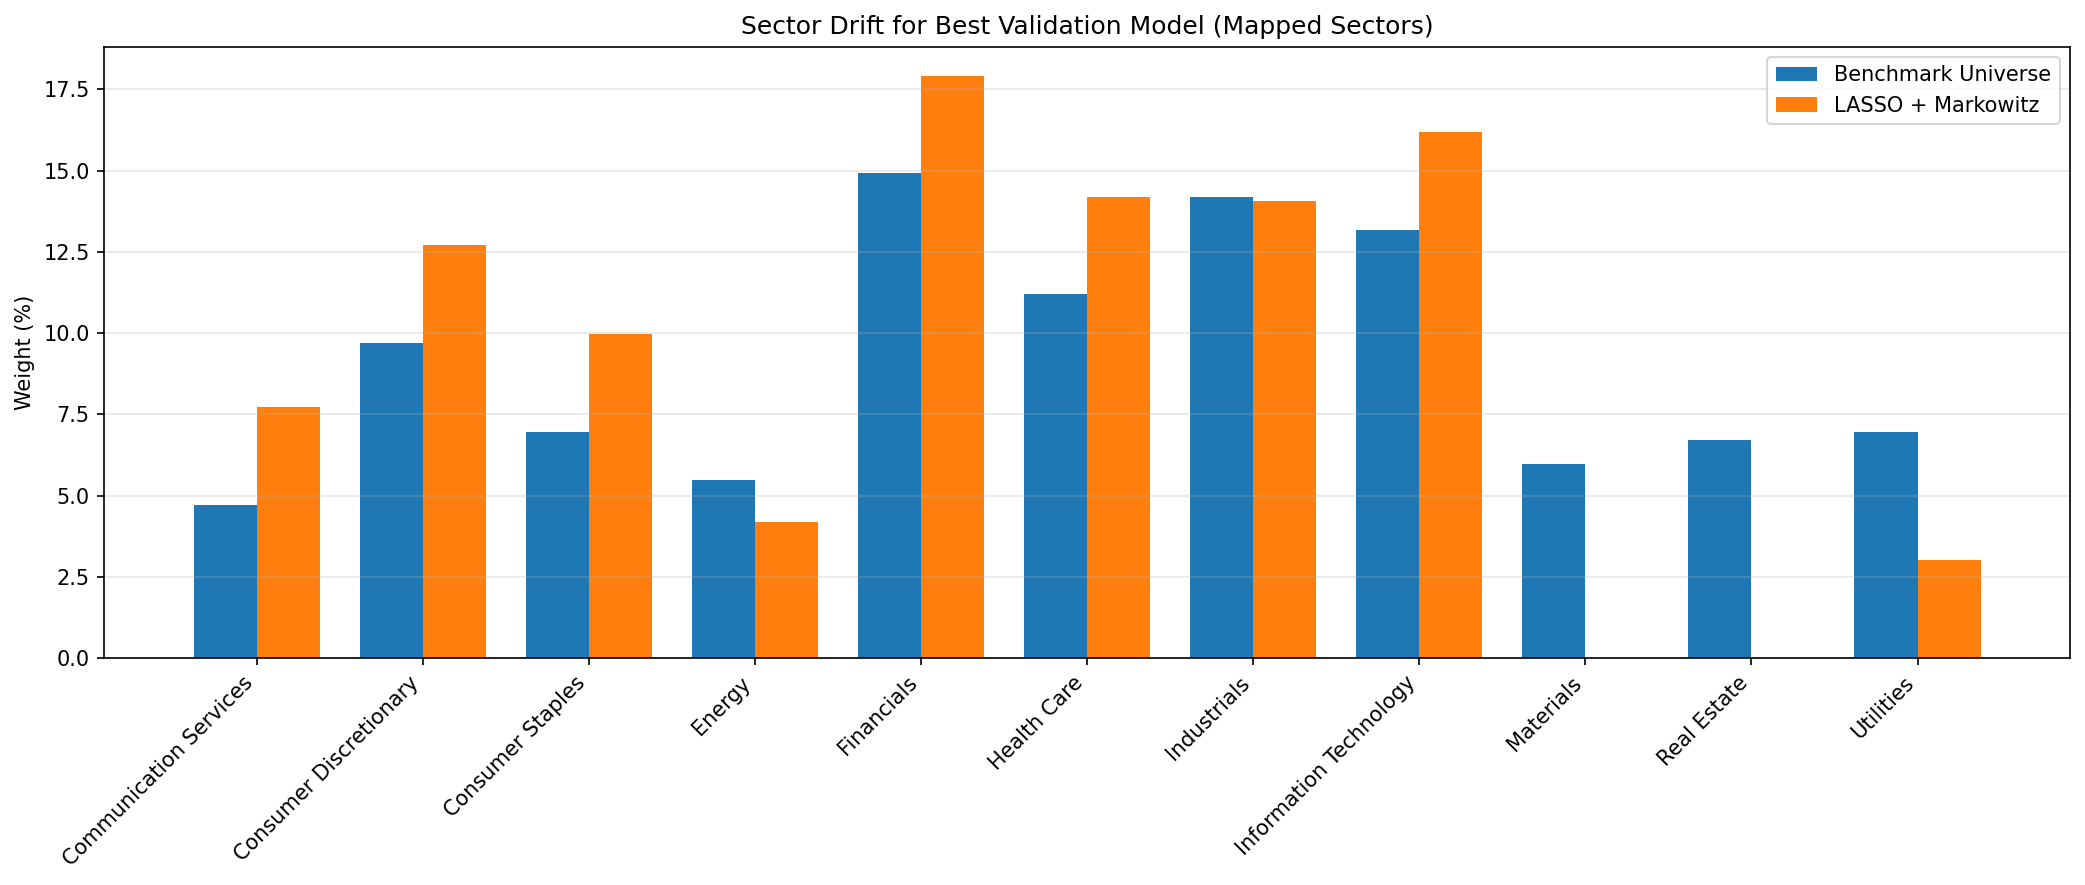

Saved fig3_sector_drift.png


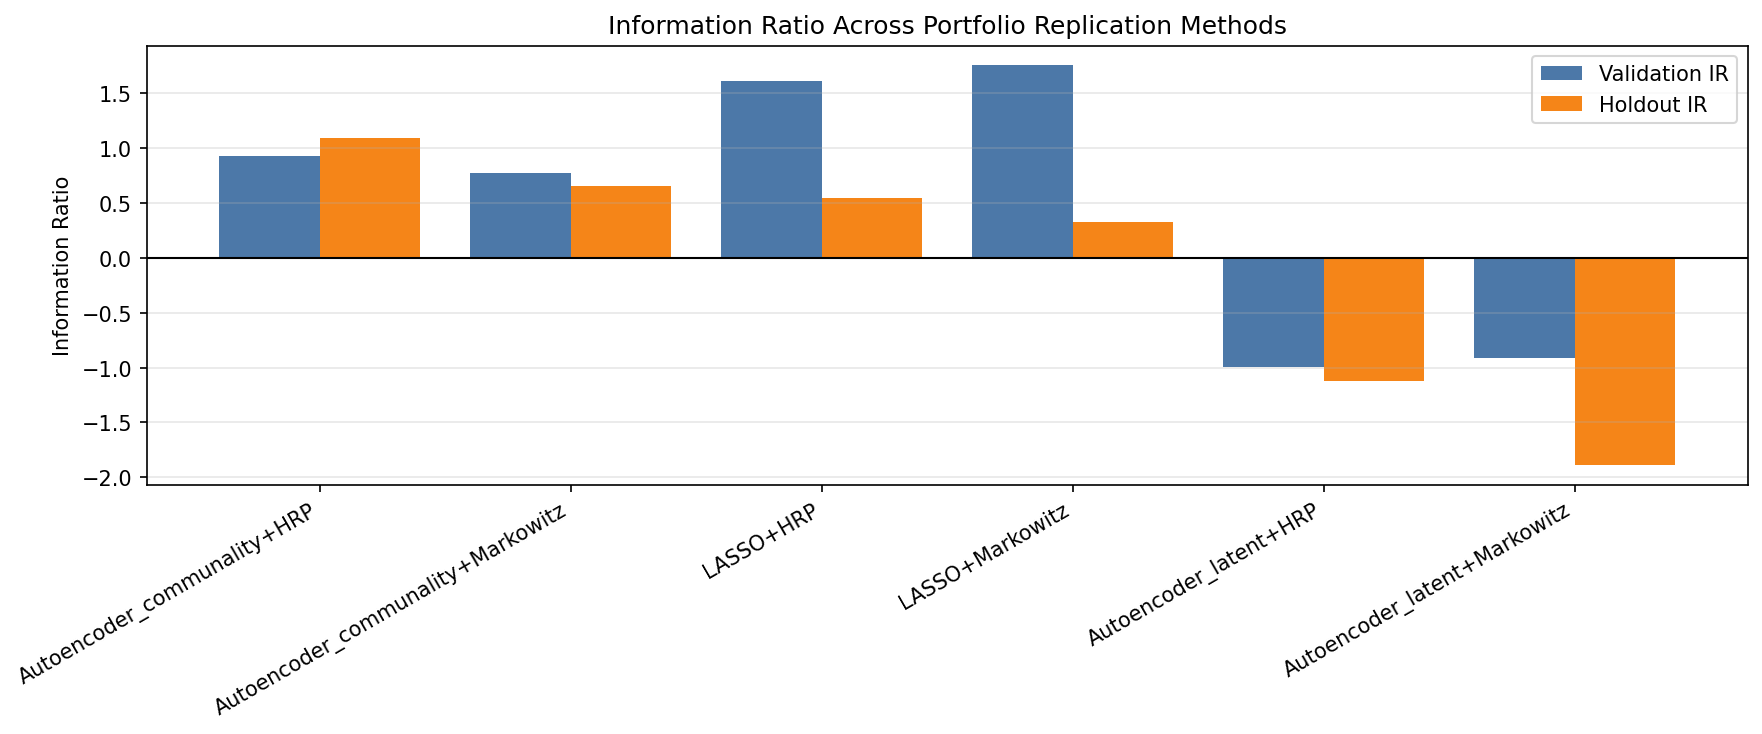

Saved fig4_information_ratio.png


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# 6. REPORT PLOTS
# ──────────────────────────────────────────────────────────────────────────────
sweeps = [
    (sweep_lasso_mk, "LASSO + Markowitz"),
    (sweep_lasso_hrp, "LASSO + HRP"),
    (sweep_ae_latent_mk, "Autoencoder Latent + Markowitz"),
    (sweep_ae_latent_hrp, "Autoencoder Latent + HRP"),
    (sweep_ae_comm_mk, "Autoencoder Communality + Markowitz"),
    (sweep_ae_comm_hrp, "Autoencoder Communality + HRP"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, (sw, title) in zip(axes.ravel(), sweeps):
    ax.plot(sw["k"], sw["TE_valid"], "o-", lw=2, color="#1f77b4", label="Rolling Validation TE")
    ax.plot(sw["k"], sw["TE_holdout"], "s--", lw=2, color="#ff7f0e", label="Holdout TE")
    ax.fill_between(sw["k"], sw["TE_valid"] - sw["TE_valid_std"], sw["TE_valid"] + sw["TE_valid_std"],
                    color="#1f77b4", alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Number of Stocks (k)")
    ax.set_ylabel("Annualised Tracking Error (%)")
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("./Outputs", "fig2_sparsity_vs_te.png"), bbox_inches="tight")
plt.show()
print("Saved fig2_sparsity_vs_te.png")

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(best_sector_df))
width = 0.38
ax.bar(x - width / 2, best_sector_df["Benchmark Weight"] * 100, width=width, label="Benchmark Universe")
ax.bar(x + width / 2, best_sector_df["Portfolio Weight"] * 100, width=width,
       label=f"{best_model_key[0]} + {best_model_key[1]}")
ax.set_xticks(x)
ax.set_xticklabels(best_sector_df["Sector"], rotation=45, ha="right")
ax.set_ylabel("Weight (%)")
ax.set_title("Sector Drift for Best Validation Model (Mapped Sectors)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("./Outputs", "fig3_sector_drift.png"), bbox_inches="tight")
plt.show()
print("Saved fig3_sector_drift.png")

ir_rows = []
for (method, weighting), result in results_all.items():
    ir_rows.append(
        {
            "Model": f"{method}+{weighting}",
            "Rolling Val TE": result["cv_te_mean"],
            "Holdout IR": result["metrics_hold"]["Ann IR"],
            "Validation IR": result["metrics_valid"]["Ann IR"],
        }
    )
df_ir = pd.DataFrame(ir_rows).sort_values("Holdout IR", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_ir))
ax.bar(x - 0.2, df_ir["Validation IR"], width=0.4, label="Validation IR", color="#4c78a8")
ax.bar(x + 0.2, df_ir["Holdout IR"], width=0.4, label="Holdout IR", color="#f58518")
ax.set_xticks(x)
ax.set_xticklabels(df_ir["Model"], rotation=30, ha="right")
ax.set_ylabel("Information Ratio")
ax.set_title("Information Ratio Across Portfolio Replication Methods")
ax.axhline(0, color="black", lw=1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("./Outputs", "fig4_information_ratio.png"), bbox_inches="tight")
plt.show()
print("Saved fig4_information_ratio.png")

### Section 8: Active Returns and Tracking Error Over Time

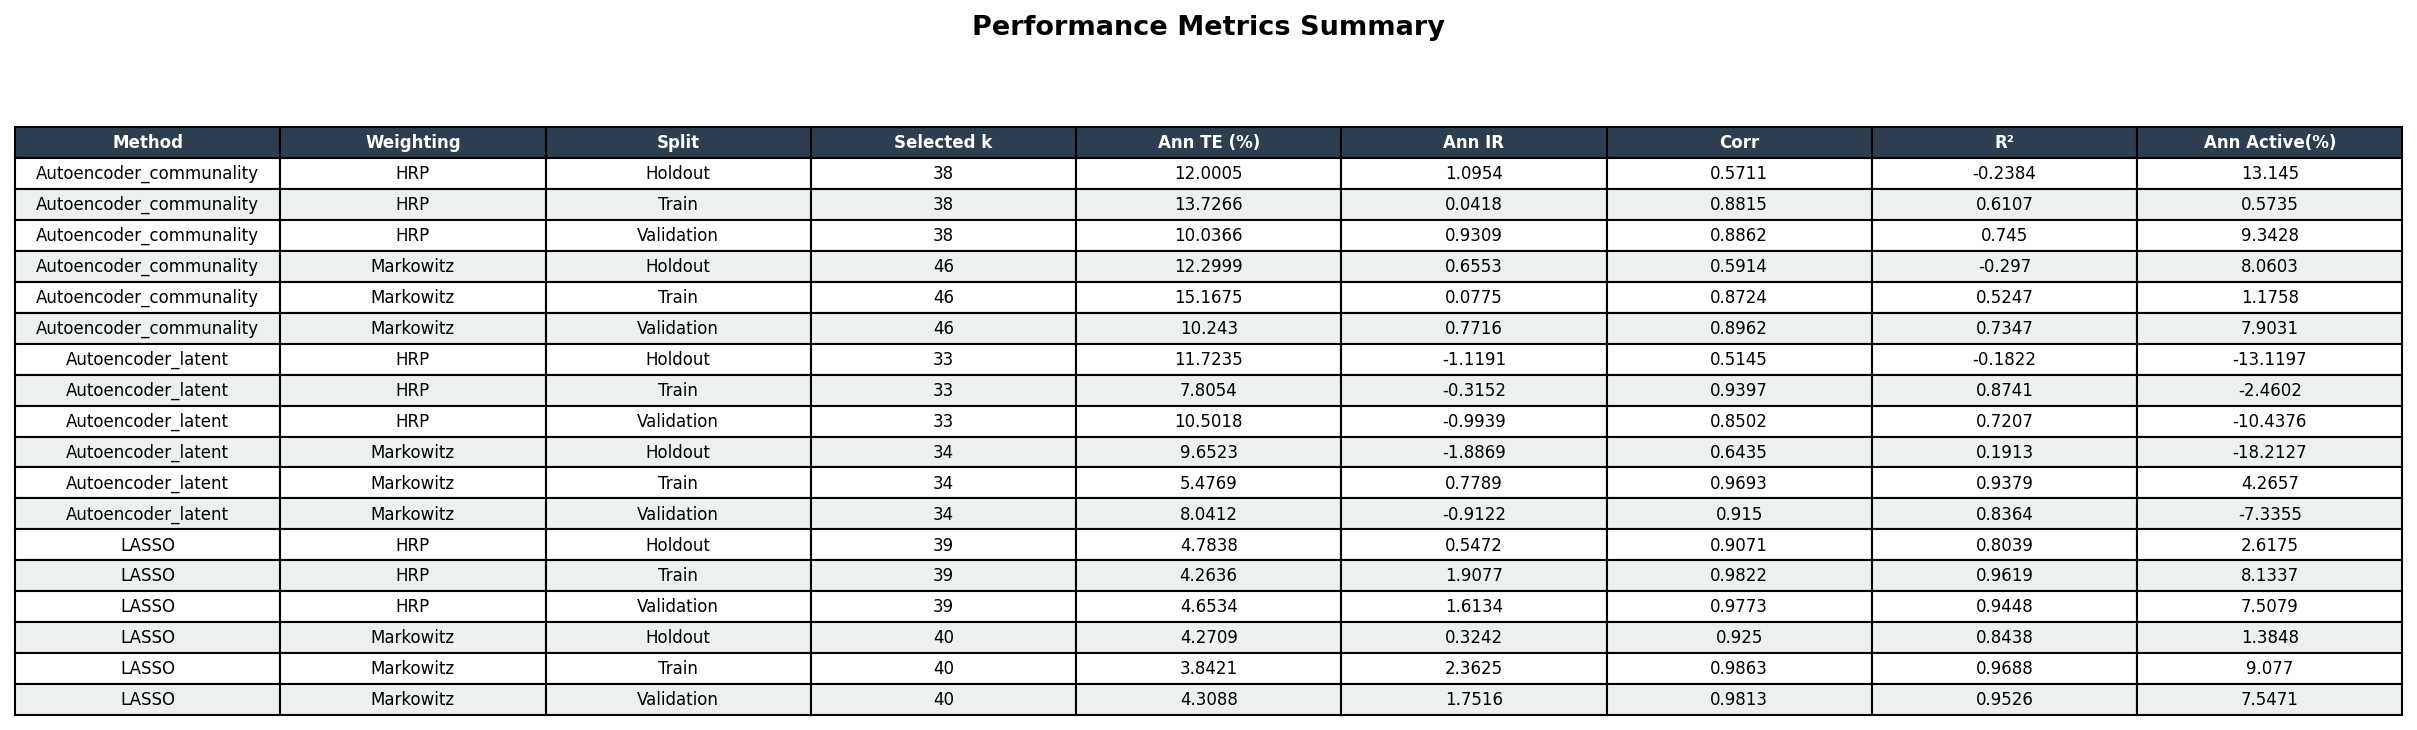

Saved fig5_metrics_table.png

Metrics summary:
                 Method Weighting      Split  Selected k  Ann TE (%)    Ann IR     Corr        R²  Ann Active(%)
Autoencoder_communality       HRP    Holdout          38   12.000456  1.095376 0.571085 -0.238440      13.145007
Autoencoder_communality       HRP      Train          38   13.726574  0.041782 0.881505  0.610715       0.573523
Autoencoder_communality       HRP Validation          38   10.036614  0.930869 0.886153  0.745041       9.342773
Autoencoder_communality Markowitz    Holdout          46   12.299890  0.655313 0.591377 -0.297024       8.060273
Autoencoder_communality Markowitz      Train          46   15.167454  0.077524 0.872378  0.524690       1.175843
Autoencoder_communality Markowitz Validation          46   10.243007  0.771556 0.896246  0.734734       7.903051
     Autoencoder_latent       HRP    Holdout          33   11.723542 -1.119087 0.514544 -0.182192     -13.119658
     Autoencoder_latent       HRP      Train     

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# 7. FINAL METRICS SUMMARY TABLE
# ──────────────────────────────────────────────────────────────────────────────
rows = []
for (method, weighting), result in results_all.items():
    for split_name, metrics_key in [("Train", "metrics_train"), ("Validation", "metrics_valid"), ("Holdout", "metrics_hold")]:
        row = result[metrics_key].copy()
        row["Method"] = method
        row["Weighting"] = weighting
        row["Split"] = split_name
        row["Selected k"] = result["k"]
        rows.append(row)

df_metrics = pd.DataFrame(rows)[
    ["Method", "Weighting", "Split", "Selected k", "Ann TE (%)", "Ann IR", "Corr", "R²", "Ann Active(%)"]
].sort_values(["Method", "Weighting", "Split"])

display_df = df_metrics.copy()
numeric_cols = display_df.select_dtypes(include=[np.number]).columns
display_df[numeric_cols] = display_df[numeric_cols].round(4)

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")
tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.15, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#ecf0f1")
fig.suptitle("Performance Metrics Summary", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join("./Outputs", "fig5_metrics_table.png"), bbox_inches="tight")
plt.show()
print("Saved fig5_metrics_table.png")

print("\nMetrics summary:")
print(df_metrics.to_string(index=False))
print("\nBest model constituents:")
print(results_all[best_model_key]["selected"])